Goals are to visualize the support vectors across models

# Packages and directory

In [39]:
#libraries and dirrectory 
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.optimize import curve_fit
import patientFunctions as ptfn
import seaborn as sns
import matplotlib.pyplot as plt
import re
import matplotlib.patches as mpatches


In [40]:
#updates to directory management
# machine_directory = 'C:/Users/mcremer' #the C and path to the project folder
machine_directory = 'C:/Users/maega' #when working from home machine
storage_directory = 'UFL Dropbox/Maegan Cremer/research-share/Maegan/Projects' #Local, HPG, or dropbox
project_directory = 'Cardiac-Amyloidosis-Multiple-Myeloma' #project folder
project_lv2_directory = '019_1_Mistic_ClinicalSplit_CodeOcean' #deeper part of project folder

path = os.path.join(machine_directory, storage_directory, 
                    project_directory, project_lv2_directory)

# parent_dir = path
outputDir = path
os.chdir(outputDir)

# importing files

In [41]:
data_first = pd.read_excel("Mistic_ClinSplit_OutcomesTables.xlsx", sheet_name= "All Features SupportVectors")
data_second = pd.read_excel("Mistic_ClinSplit_OutcomesTables.xlsx", sheet_name='Reduced Features SupportVectors')


In [42]:
data_first

,DeID,CA_status_yes,decision value,counts,model
0,W-01,1,1.300797,5,EchoAdj
1,X-01,1,0.978975,1,EchoAdj
2,X-02,1,0.835916,4,EchoAdj
3,A-02,0,-0.469646,3,EchoAdj
4,C-02,0,-1.292018,4,EchoAdj
...,...,...,...,...,...
100,M-02,1,1.385237,5,DescFits
101,Q-02,1,2.121641,5,DescFits
102,Q-03,1,1.912386,1,DescFits
103,O-03,1,0.873811,1,DescFits


# plots

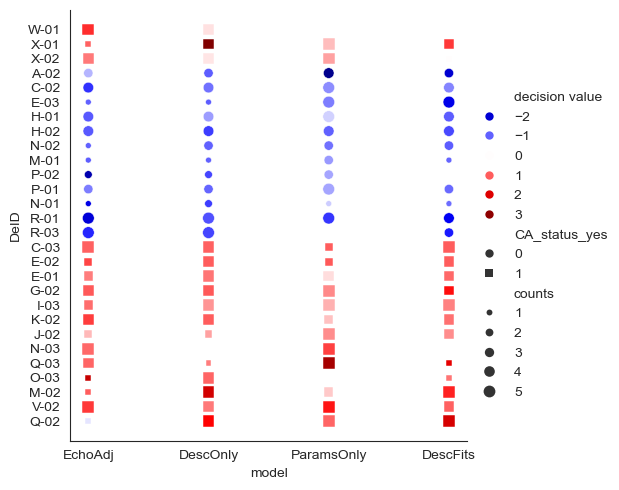

In [43]:
data = data_first
sns.set_style('white')

sns.relplot(data = data, x = 'model', y = 'DeID', hue= 'decision value', palette= 'seismic', size = 'counts', style= 'CA_status_yes',
            markers=['o','s'],  hue_norm=(-3.2,3.2))



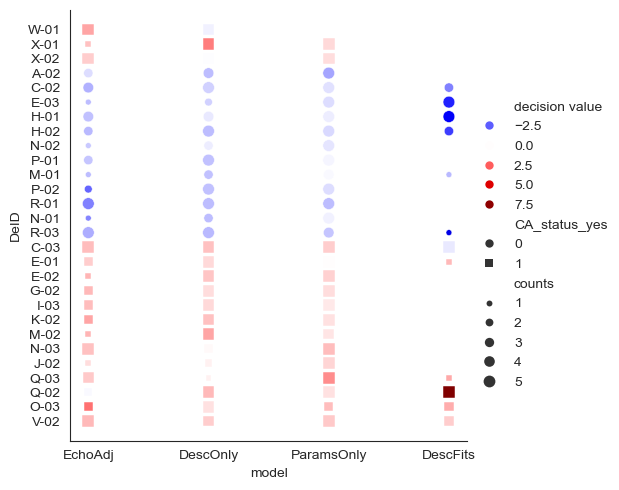

In [44]:
data = data_second

sns.relplot(data = data, x = 'model', y = 'DeID', hue= 'decision value', palette= 'seismic', size = 'counts',
            markers=['o', 's'], style= 'CA_status_yes', hue_norm=(-7.96,7.96,))


In [45]:
data_second['model'] = [model + ' simplified' for model in data_second['model']]
bothRounds = pd.concat([data_first, data_second], axis = 0)

In [46]:
data_second['decision value'].max()

7.952703765896748

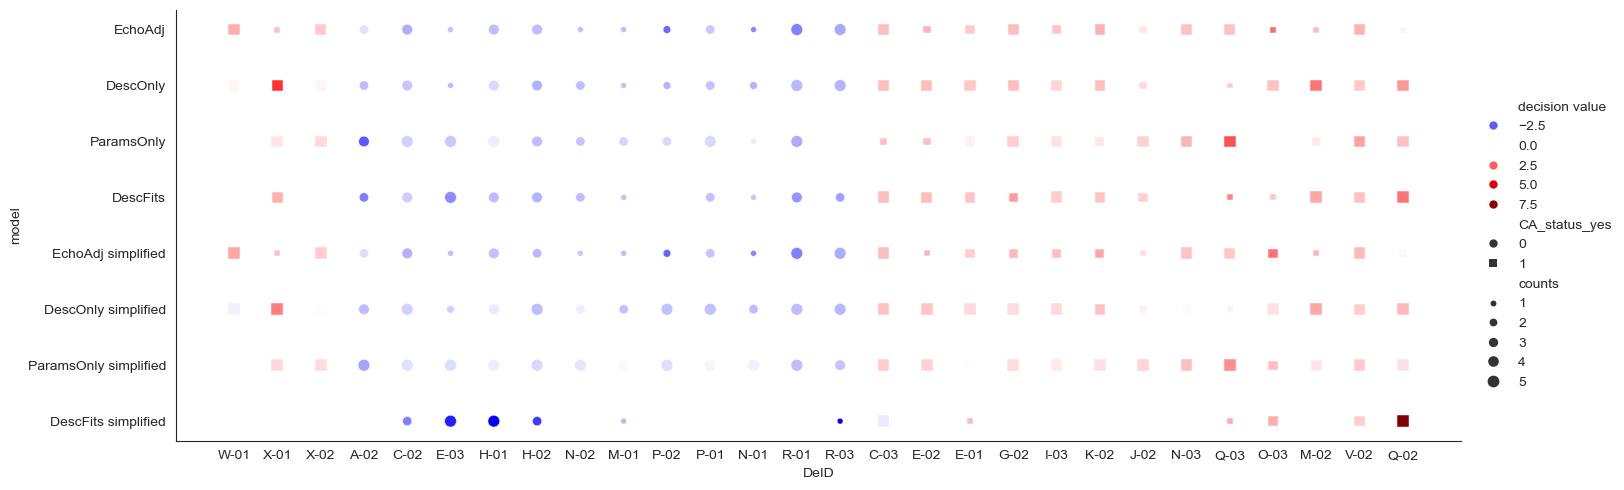

In [47]:
sns.relplot(data = bothRounds, y = 'model', x= 'DeID', hue= 'decision value', palette= 'seismic', size = 'counts', style= 'CA_status_yes',
             hue_norm=(-7.96,7.96), aspect = 3,
             markers = ['o', 's'])
# plt.xticks(rotation = 90)
